# AF 6: Aprendizaje supervisado, árbol de decisión

---
Hora: N5  Grupo: 007  Salon: 12106

José Juan Tamez Robledo             2001926

Ana Patricia Aguirre Leyzaola       2178178

Jorge Angel de Alejandro Martinez   2066801

Kevin Alejandro Sifuentes Martinez  2067313

Ricardo Alfredo Zumaya Osorio       2178139


---



# Importar librerías.

In [30]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Cargar datos

In [31]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

len(y)
y[0]
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

# Preprocesamiento

In [32]:
# 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Selección y entrenamiento del modelo

In [33]:
clf = DecisionTreeClassifier()

In [34]:
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [35]:
train_accuracy = clf.score(X_train, y_train)
print(train_accuracy)

1.0


# Prueba del modelo

In [36]:
y_pred = clf.predict(X_test)

In [37]:
conf_matrix = confusion_matrix(y_test, y_pred)

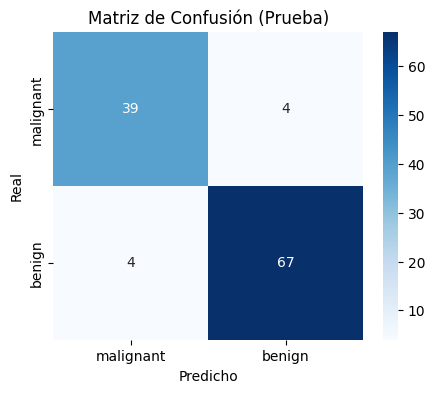

In [38]:


plt.figure(figsize=(5,4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Prueba)")
plt.show()

In [39]:
# Predicción 1
print(y_pred[1])
print(y_test[1])

0
0


In [40]:
# Predicción 2
print(y_pred[20])
print(y_test[20])

1
0


In [41]:
# Predicción 3
print(y_pred[-1])
print(y_test[-1])

0
0


In [42]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Classification Report:\n",
      classification_report(y_test, y_pred, target_names=cancer.target_names))

Accuracy: 0.9298245614035088
Classification Report:
               precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        43
      benign       0.94      0.94      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



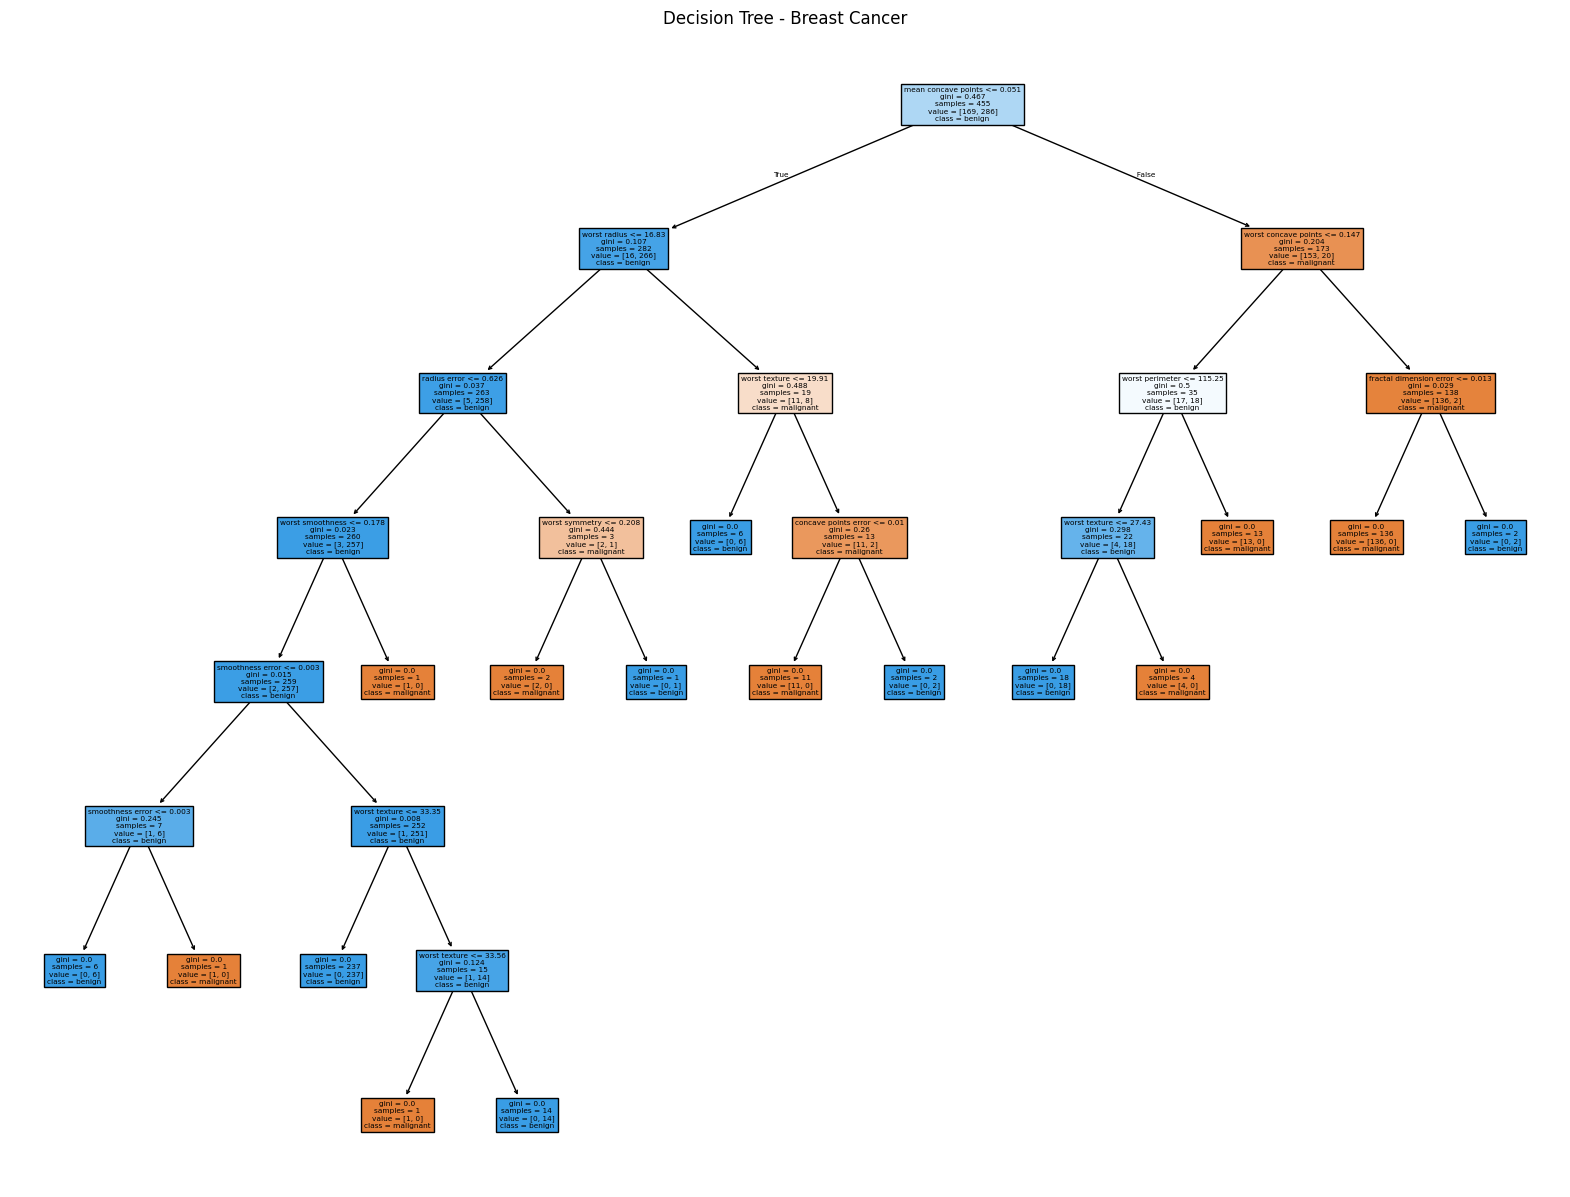

In [43]:
plt.figure(figsize=(20, 15))

tree.plot_tree(
    clf,
    filled=True,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names
)

plt.title("Decision Tree - Breast Cancer")

plt.savefig("decision_tree.png", dpi=300)
plt.show()